In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
# Sample dataset of movie reviews and their corresponding sentiment labels
texts = [

    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I enjoyed the movie",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever",
    "I disliked the movie"

]

# 1 = Positive sentiment
# 0 = Negative sentiment

labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [20]:
# The tokenizer gives every word a number. 
# Initialize the Tokenizer # numbering depends on the frequency of the word in the dataset. The most frequent word gets the lowest number (1), and so on.
# if the frequency of a word is the same as another word, then the numbering is based on the order of appearance in the dataset. 
# The word that appears first gets the lower number.


tokenizer = Tokenizer()

# Learn vocabulary from the training texts
tokenizer.fit_on_texts(texts)

# Convert each sentence into a sequence of numbers
sequences = tokenizer.texts_to_sequences(texts)

print("Word Index:")
print(tokenizer.word_index)


print("\nSequences:")
print(sequences)

Word Index:
{'i': 1, 'movie': 2, 'this': 3, 'film': 4, 'very': 5, 'acting': 6, 'story': 7, 'the': 8, 'love': 9, 'is': 10, 'amazing': 11, 'good': 12, 'excellent': 13, 'enjoyed': 14, 'hate': 15, 'terrible': 16, 'boring': 17, 'worst': 18, 'ever': 19, 'disliked': 20}

Sequences:
[[1, 9, 3, 2], [3, 4, 10, 11], [5, 12, 6], [13, 7], [1, 14, 8, 2], [1, 15, 3, 2], [16, 4], [5, 17, 7], [18, 6, 19], [1, 20, 8, 2]]


In [5]:
# Pad the sequences to ensure they all have the same length (for RNN input) 
# The max_length is the maximum length of the sequences. If a sequence is shorter than the max_length, it will be padded with zeros at the end (post-padding). 
#  If a sequence is longer than the max_length, it will be truncated to fit the max_length.


max_length = 5

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("\nPadded Sequences:")
print(X)


Padded Sequences:
[[ 1  9  3  2  0]
 [ 3  4 10 11  0]
 [ 5 12  6  0  0]
 [13  7  0  0  0]
 [ 1 14  8  2  0]
 [ 1 15  3  2  0]
 [16  4  0  0  0]
 [ 5 17  7  0  0]
 [18  6 19  0  0]
 [ 1 20  8  2  0]]


In [ ]:
model = Sequential()

# Embedding layer:
# Converts each word number into a small vector of fixed size (8 in this case).
# The input_dim is the size of the vocabulary (number of unique words + 1 for padding).  
# +1 because the word index starts from 1, and 0 is reserved for padding.
# the output_dim is the size of the embedding vector for each word.
# The input_length is the length of the input sequences (max_length).


model.add(Embedding( 
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=8,
    input_length=max_length
))

# SimpleRNN layer:
# Reads the sentence word by word and keeps memory
# hidden state size = 8 because we have a small dataset and want to keep the model simple.
model.add(SimpleRNN(8))


# Dense output layer:
# sigmoid gives output between 0 and 1
# 1 for positive sentiment and 0 for negative sentiment.
model.add(Dense(1, activation="sigmoid"))

/Users/swatichandna/.pyenv/versions/3.11.7/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:


model.compile(
    optimizer="adam", # adjusts the learning rate during training to improve convergence.
    loss="binary_crossentropy", #How bad the preddictions are compared to the true labels. Binary crossentropy is used for binary classification problems.
    metrics=["accuracy"]

)

In [15]:
history = model.fit(

    X,
    labels,
    epochs=200,
    verbose=1 #verbose=1 means that the training progress will be displayed in the console, showing the loss and accuracy for each epoch.
    

)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9000 - loss: 0.6264
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9000 - loss: 0.6229
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9000 - loss: 0.6193
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9000 - loss: 0.6156
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.6118
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9000 - loss: 0.6078
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.6038
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.5995
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.5952
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.5907
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9000 - loss: 0.5861
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - lo

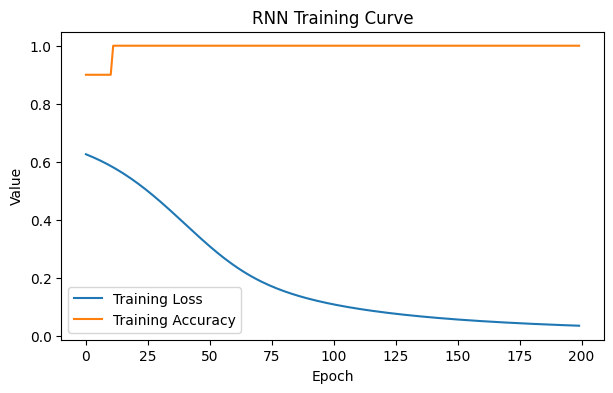

In [16]:

# Plot the training loss and accuracy curves
#
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.title("RNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
test_texts = [
    "I love the story",
    "This movie is boring",
    "Excellent acting",
    "Worst film"
]

test_sequences = tokenizer.texts_to_sequences(test_texts)

test_X = pad_sequences(
    test_sequences,
    maxlen=max_length,
    padding="post"
)

predictions = model.predict(test_X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [21]:

for text, prediction in zip(test_texts, predictions):
    score = prediction[0]
    if score >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print(text, "→", sentiment, "score:", score)

I love the story → Positive score: 0.96209824
This movie is boring → Positive score: 0.9581923
Excellent acting → Positive score: 0.7851696
Worst film → Negative score: 0.041912884
